# Random Forest — Clasificacion PYME en Contratacion Publica TED
**Input:** `dataset_preprocessed_ES_SME.csv`  
**Target:** `B_CONTRACTOR_SME` → PYME=1 / No-PYME=0

In [6]:
!pip install pandas numpy scikit-learn matplotlib seaborn -q


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

BG, AX, TEXT = '#0f1117', '#161b2e', '#dce1f0'
ACC, ACC2, MUTED = '#4cc9f0', '#f72585', '#8892b0'
GREEN = '#06d6a0'
ORANGE = '#ffd166'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX, 'axes.edgecolor': '#252a40',
    'axes.labelcolor': TEXT, 'axes.titlecolor': TEXT, 'xtick.color': MUTED,
    'ytick.color': MUTED, 'text.color': TEXT, 'grid.color': '#252a40',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlepad': 11,
    'legend.facecolor': AX, 'legend.edgecolor': '#252a40',
})
print(' OK')

 OK


## 1. Carga del dataset preprocesado

In [8]:
CSV_PATH = 'dataset_preprocessed_ES_SME.csv'
# En Colab → descomenta:
# from google.colab import files; up = files.upload(); CSV_PATH = list(up.keys())[0]

for enc in ['utf-8', 'latin-1', 'cp1252']:
    try:
        df = pd.read_csv(CSV_PATH, low_memory=False, encoding=enc)
        print(f' Cargado ({enc}) — {df.shape[0]:,} filas x {df.shape[1]} cols')
        break
    except UnicodeDecodeError:
        continue

# Separar features y target
X = df.drop(columns=['TARGET'])
y = df['TARGET']

print(f'Features : {X.shape[1]}')
print(f'Balance  : PYME={y.mean()*100:.1f}%  No-PYME={(1-y.mean())*100:.1f}%')

 Cargado (utf-8) — 232,665 filas x 32 cols
Features : 31
Balance  : PYME=45.4%  No-PYME=54.6%


## 3. Split train / test

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train : {X_train.shape[0]:,} filas  | PYME: {y_train.mean()*100:.1f}%')
print(f'Test  : {X_test.shape[0]:,} filas  | PYME: {y_test.mean()*100:.1f}%')

# Calcular class_weight automaticamente
classes = np.array([0, 1])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(f'\nClass weights (balanced): {class_weight_dict}')

Train : 186,132 filas  | PYME: 45.4%
Test  : 46,533 filas  | PYME: 45.4%

Class weights (balanced): {np.int64(0): np.float64(0.9153642631625537), np.int64(1): np.float64(1.1018813416843276)}


## 4. Entrenamiento — Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators     = 300,       # suficiente para estabilizar OOB error
    max_depth        = None,      
    min_samples_leaf = 5,         # evita overfitting en hojas muy pequeñas
    max_features     = 'sqrt',    # sqrt(n_features) — estandar para clasificacion
    class_weight     = 'balanced',# compensa desbalance automaticamente
    n_jobs           = -1,        # usa todos los CPUs
    oob_score        = True,      
    random_state     = 42,
    verbose          = 1              
)

rf.fit(X_train, y_train)
print(f'\n Entrenamiento completado')
print(f'   OOB Score (accuracy aprox): {rf.oob_score_:.4f}')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    8.6s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   14.3s finished



 Entrenamiento completado
   OOB Score (accuracy aprox): 0.8349


## 5. Balanceo de clases

El dataset tiene 45.4% PYME y 54.6% No-PYME. El desbalance es moderado pero vale la pena comparar tres estrategias para ver si mejoran el recall de la clase minoritaria.

In [11]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score
import pandas as pd
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Distribucion original train:')
print(f'  No-PYME: {(y_train==0).sum():,}  ({(y_train==0).mean()*100:.1f}%)')
print(f'  PYME   : {(y_train==1).sum():,}  ({(y_train==1).mean()*100:.1f}%)')


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Distribucion original train:
  No-PYME: 101,671  (54.6%)
  PYME   : 84,461  (45.4%)


In [12]:
# --- Estrategia 1: class_weight='balanced' (ya usada, referencia) ---
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    max_features='sqrt', class_weight='balanced',
    n_jobs=-1, random_state=42
)
rf_base.fit(X_train, y_train)
y_prob_base = rf_base.predict_proba(X_test)[:,1]
y_pred_base = rf_base.predict(X_test)

print('--- class_weight=balanced (referencia) ---')
print(classification_report(y_test, y_pred_base, target_names=['No-PYME','PYME']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_base):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_base):.4f}')

--- class_weight=balanced (referencia) ---
              precision    recall  f1-score   support

     No-PYME       0.86      0.83      0.85     25418
        PYME       0.80      0.84      0.82     21115

    accuracy                           0.83     46533
   macro avg       0.83      0.83      0.83     46533
weighted avg       0.84      0.83      0.83     46533

ROC-AUC : 0.9213
PR-AUC  : 0.9055


In [13]:
# --- Estrategia 2: SMOTE (oversampling sintetico de la clase minoritaria) ---
sm = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = sm.fit_resample(X_train, y_train)

print(f'Distribucion tras SMOTE:')
print(f'  No-PYME: {(y_sm==0).sum():,}')
print(f'  PYME   : {(y_sm==1).sum():,}')

rf_smote = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    max_features='sqrt', n_jobs=-1, random_state=42
)
rf_smote.fit(X_sm, y_sm)
y_prob_smote = rf_smote.predict_proba(X_test)[:,1]
y_pred_smote = rf_smote.predict(X_test)

print()
print('--- SMOTE ---')
print(classification_report(y_test, y_pred_smote, target_names=['No-PYME','PYME']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_smote):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_smote):.4f}')

Distribucion tras SMOTE:
  No-PYME: 101,671
  PYME   : 101,671

--- SMOTE ---
              precision    recall  f1-score   support

     No-PYME       0.86      0.84      0.85     25418
        PYME       0.81      0.83      0.82     21115

    accuracy                           0.83     46533
   macro avg       0.83      0.83      0.83     46533
weighted avg       0.84      0.83      0.83     46533

ROC-AUC : 0.9212
PR-AUC  : 0.9057


In [14]:
# --- Estrategia 3: Undersampling (reducir la clase mayoritaria) ---
rus = RandomUnderSampler(random_state=42)
X_under, y_under = rus.fit_resample(X_train, y_train)

print(f'Distribucion tras Undersampling:')
print(f'  No-PYME: {(y_under==0).sum():,}')
print(f'  PYME   : {(y_under==1).sum():,}')

rf_under = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=5,
    max_features='sqrt', n_jobs=-1, random_state=42
)
rf_under.fit(X_under, y_under)
y_prob_under = rf_under.predict_proba(X_test)[:,1]
y_pred_under = rf_under.predict(X_test)

print()
print('--- Undersampling ---')
print(classification_report(y_test, y_pred_under, target_names=['No-PYME','PYME']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_under):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_under):.4f}')

Distribucion tras Undersampling:
  No-PYME: 84,461
  PYME   : 84,461

--- Undersampling ---
              precision    recall  f1-score   support

     No-PYME       0.87      0.82      0.84     25418
        PYME       0.79      0.85      0.82     21115

    accuracy                           0.83     46533
   macro avg       0.83      0.83      0.83     46533
weighted avg       0.83      0.83      0.83     46533

ROC-AUC : 0.9194
PR-AUC  : 0.9028


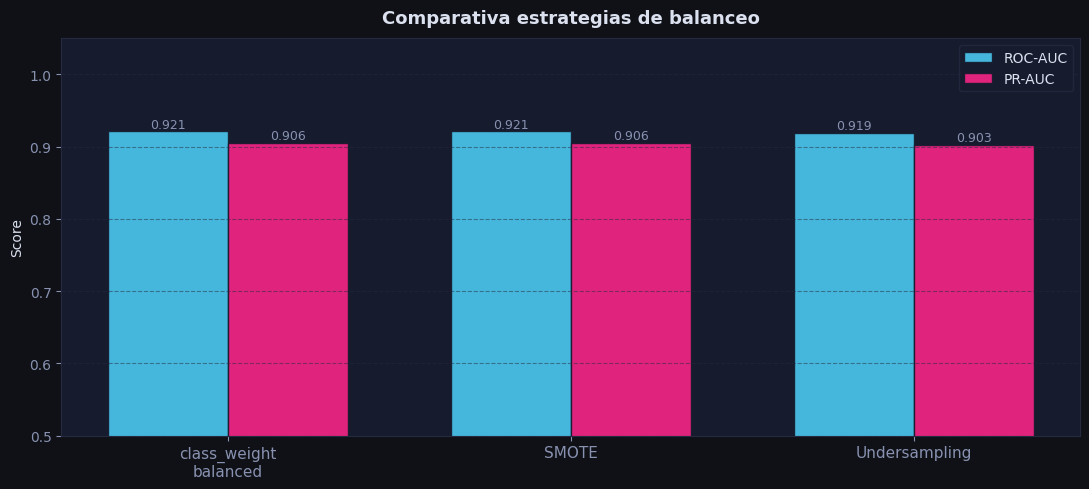

In [15]:
# --- Comparativa visual ---
estrategias = ['class_weight\nbalanced', 'SMOTE', 'Undersampling']
roc_scores  = [
    roc_auc_score(y_test, y_prob_base),
    roc_auc_score(y_test, y_prob_smote),
    roc_auc_score(y_test, y_prob_under),
]
pr_scores = [
    average_precision_score(y_test, y_prob_base),
    average_precision_score(y_test, y_prob_smote),
    average_precision_score(y_test, y_prob_under),
]

x = np.arange(len(estrategias))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width/2, roc_scores, width, label='ROC-AUC', color=ACC,  edgecolor=AX, alpha=0.9)
b2 = ax.bar(x + width/2, pr_scores,  width, label='PR-AUC',  color=ACC2, edgecolor=AX, alpha=0.9)
ax.set_xticks(x)
ax.set_xticklabels(estrategias, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparativa estrategias de balanceo')
ax.legend()
ax.grid(True, axis='y')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', fontsize=9, color=MUTED)
plt.tight_layout()
plt.show()

## 6. Grid Search CV

Busqueda sistematica de hiperparametros con validacion cruzada estratificada. Se usa RandomizedSearchCV en lugar de GridSearchCV porque el espacio de busqueda es grande y RandomizedSearch da resultados equivalentes en una fraccion del tiempo.

In [16]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# Espacio de busqueda
param_dist = {
    'n_estimators'    : randint(100, 500),
    'max_depth'       : [None, 10, 20, 30, 40],
    'min_samples_leaf': randint(1, 20),
    'max_features'    : ['sqrt', 'log2', 0.3, 0.5],
    'class_weight'    : ['balanced', 'balanced_subsample'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_search = RandomForestClassifier(n_jobs=-1, random_state=42, oob_score=False)

search = RandomizedSearchCV(
    estimator          = rf_search,
    param_distributions= param_dist,
    n_iter             = 30,          # 30 combinaciones aleatorias
    scoring            = 'roc_auc',   # metrica de optimizacion
    cv                 = cv,
    n_jobs             = -1,
    verbose            = 2,
    random_state       = 42,
    refit              = True         # re-entrena con los mejores params sobre todo el train
)

search.fit(X_train, y_train)

print('\nMejores hiperparametros encontrados:')
for param, val in search.best_params_.items():
    print(f'  {param:<22}: {val}')
print(f'\nMejor ROC-AUC (CV): {search.best_score_:.4f}')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Mejores hiperparametros encontrados:
  class_weight          : balanced_subsample
  max_depth             : None
  max_features          : log2
  min_samples_leaf      : 2
  n_estimators          : 439

Mejor ROC-AUC (CV): 0.9232


In [17]:
# Evaluacion del mejor modelo sobre test
best_rf = search.best_estimator_
y_prob_best = best_rf.predict_proba(X_test)[:,1]
y_pred_best = best_rf.predict(X_test)

print('--- Mejor modelo (Grid Search) sobre test ---')
print(classification_report(y_test, y_pred_best, target_names=['No-PYME','PYME']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_best):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_prob_best):.4f}')

--- Mejor modelo (Grid Search) sobre test ---
              precision    recall  f1-score   support

     No-PYME       0.86      0.84      0.85     25418
        PYME       0.82      0.84      0.83     21115

    accuracy                           0.84     46533
   macro avg       0.84      0.84      0.84     46533
weighted avg       0.84      0.84      0.84     46533

ROC-AUC : 0.9262
PR-AUC  : 0.9093


In [18]:
# Resultados de todas las iteraciones ordenados por rank
results = pd.DataFrame(search.cv_results_)
results = results.sort_values('rank_test_score')[
    ['rank_test_score', 'mean_test_score', 'std_test_score',
     'param_n_estimators', 'param_max_depth',
     'param_min_samples_leaf', 'param_max_features', 'param_class_weight']
].head(15)
results.columns = ['Rank', 'ROC-AUC medio', 'Std',
                   'n_estimators', 'max_depth',
                   'min_samples_leaf', 'max_features', 'class_weight']
results = results.round(4)
print('Top 15 combinaciones:')
display(results)

Top 15 combinaciones:


,Rank,ROC-AUC medio,Std,n_estimators,max_depth,min_samples_leaf,max_features,class_weight
10,1,0.9232,0.0010,439,None,2,log2,balanced_subsample
22,2,0.9228,0.0012,330,None,5,0.3,balanced
23,3,0.9215,0.0014,300,None,7,0.5,balanced_subsample
7,4,0.9212,0.0014,406,20,3,0.5,balanced_subsample
26,5,0.9205,0.0012,326,20,1,0.3,balanced_subsample
24,6,0.9203,0.0011,147,30,1,log2,balanced_subsample
20,7,0.9203,0.0015,162,None,8,0.5,balanced_subsample
2,8,0.9189,0.0013,459,20,4,0.3,balanced
9,9,0.9153,0.0014,341,None,14,0.5,balanced_subsample
1,10,0.9150,0.0013,221,40,7,sqrt,balanced_subsample


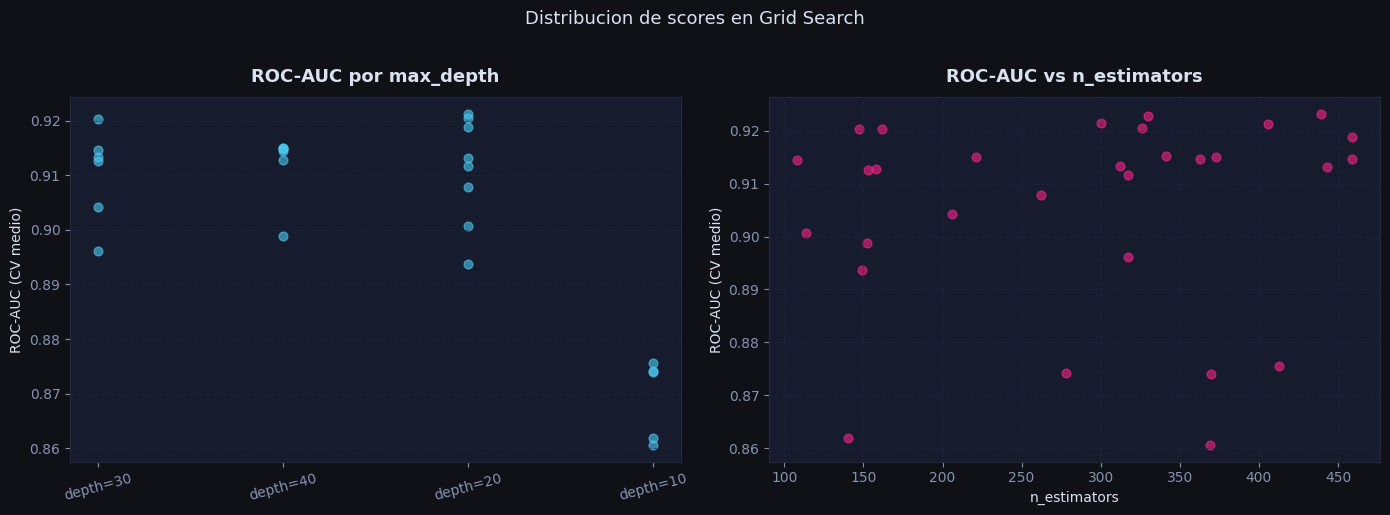

In [19]:
# Visualizacion: distribucion de scores por hiperparametro
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# max_depth
cv_res = pd.DataFrame(search.cv_results_)
for depth in cv_res['param_max_depth'].unique():
    mask = cv_res['param_max_depth'] == depth
    scores = cv_res[mask]['mean_test_score']
    label = f'depth={depth}' if depth is not None else 'depth=None'
    axes[0].scatter([label]*len(scores), scores, alpha=0.6, s=40, color=ACC)
axes[0].set_title('ROC-AUC por max_depth')
axes[0].set_ylabel('ROC-AUC (CV medio)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(True, axis='y')

# n_estimators
axes[1].scatter(cv_res['param_n_estimators'],
                cv_res['mean_test_score'],
                alpha=0.6, s=40, color=ACC2)
axes[1].set_title('ROC-AUC vs n_estimators')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('ROC-AUC (CV medio)')
axes[1].grid(True)

plt.suptitle('Distribucion de scores en Grid Search', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

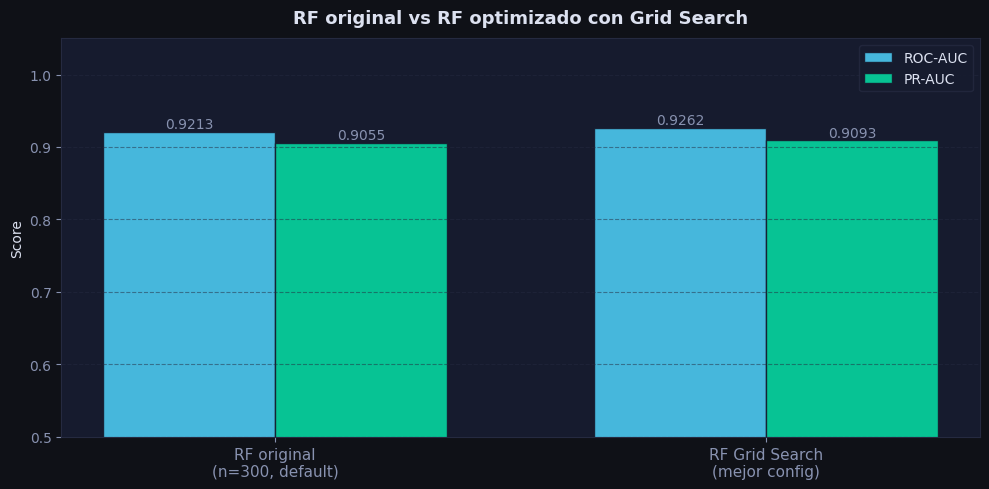


Diferencia ROC-AUC (Grid Search - original): +0.0049
Diferencia PR-AUC  (Grid Search - original): +0.0038


In [20]:
# Comparativa final: modelo original vs mejor modelo de grid search
modelos = ['RF original\n(n=300, default)', 'RF Grid Search\n(mejor config)']
roc_final = [
    roc_auc_score(y_test, y_prob_base),
    roc_auc_score(y_test, y_prob_best),
]
pr_final = [
    average_precision_score(y_test, y_prob_base),
    average_precision_score(y_test, y_prob_best),
]

x = np.arange(len(modelos))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - width/2, roc_final, width, label='ROC-AUC', color=ACC,  edgecolor=AX, alpha=0.9)
b2 = ax.bar(x + width/2, pr_final,  width, label='PR-AUC',  color=GREEN, edgecolor=AX, alpha=0.9)
ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=11)
ax.set_ylim(0.5, 1.05); ax.set_ylabel('Score')
ax.set_title('RF original vs RF optimizado con Grid Search')
ax.legend(); ax.grid(True, axis='y')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', fontsize=10, color=MUTED)
plt.tight_layout()
plt.show()

print('\nDiferencia ROC-AUC (Grid Search - original):',
      f'{roc_final[1]-roc_final[0]:+.4f}')
print('Diferencia PR-AUC  (Grid Search - original):',
      f'{pr_final[1]-pr_final[0]:+.4f}')